# 04. Analysis and Visualization

This notebook analyzes the trends and relationships between programming languages and domains based on StackOverflow data.

In [1]:
# --- IMPORTS ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Data

In [2]:
# Load the dataset
file_path = 'data/outputs/dataset_STACKOVERFLOW_gpt.csv'
df = pd.read_csv(file_path)

# Preview
df.head()

,source_type,raw_text,language,event_date,label_gpt
0,stackoverflow,how to cancel a “range over func” iteration ea...,go,2025,web backend
1,stackoverflow,ioptionssnapshot<t>.get(string? name) returns ...,c#,2025,developer tools
2,stackoverflow,"why am i getting an ""error: time zone ""gmt-070...",typescript,2025,data_ai
3,stackoverflow,how to make temp 2fa qr code in perl based web...,perl,2025,web backend
4,stackoverflow,how do i dynamically adjust the height of my `...,dart,2024,web frontend


## 2. Preprocessing

- Split multiple languages (comma-separated).
- Handle missing values if any.

In [3]:
# Explode 'language' column to handle multiple languages per row
df_exploded = df.assign(language=df['language'].str.split(',')).explode('language')
df_exploded['language'] = df_exploded['language'].str.strip()

# Ensure label_gpt is clean
df_exploded['label_gpt'] = df_exploded['label_gpt'].str.strip()

print(f"Total rows after explosion: {len(df_exploded)}")

Total rows after explosion: 4623


## 3. Analysis Type 1: Languages -> Domains

Show the distribution of domains for each programming language (e.g., What is Python used for?)

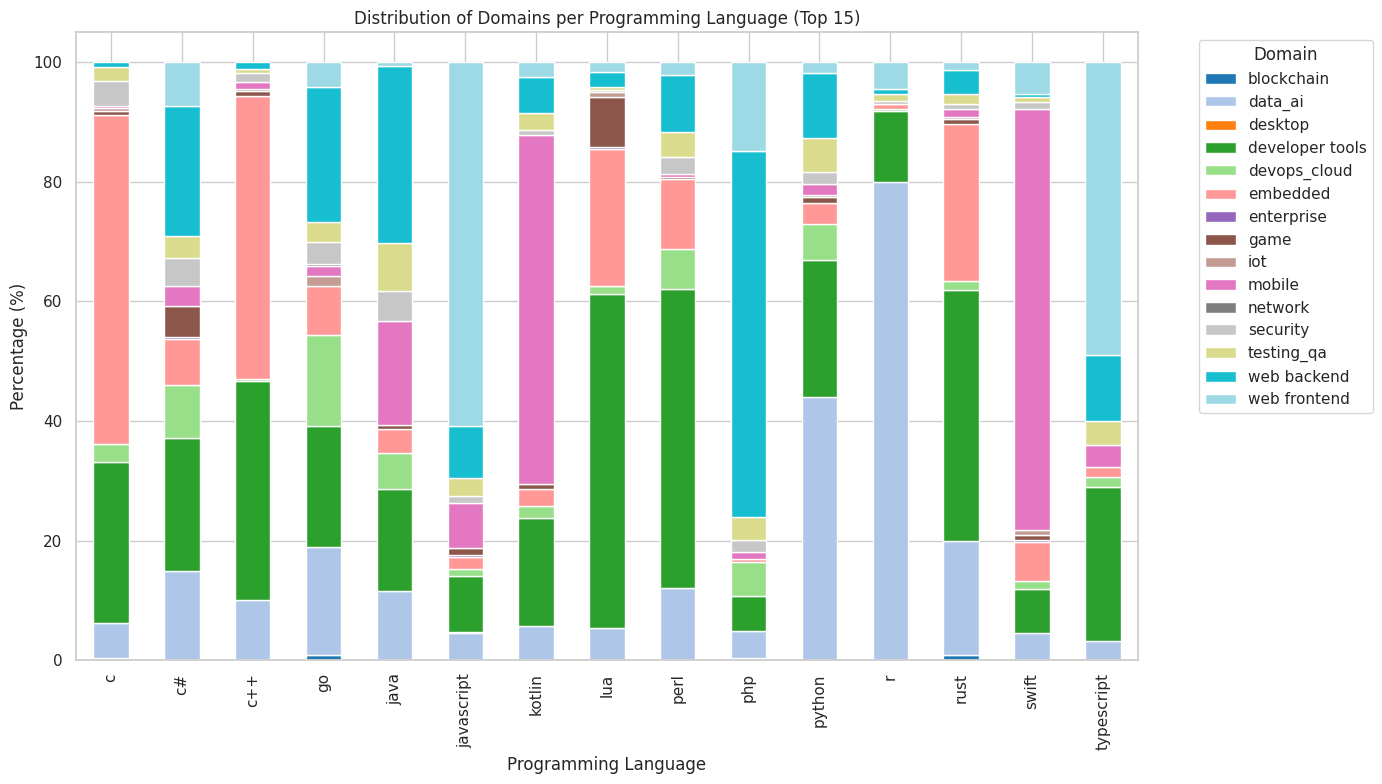

In [4]:
# Filter for top languages to keep the chart readable
top_languages = df_exploded['language'].value_counts().nlargest(15).index
df_top_lang = df_exploded[df_exploded['language'].isin(top_languages)]

# Calculate percentages
lang_domain_counts = df_top_lang.groupby(['language', 'label_gpt']).size().reset_index(name='count')
lang_total = df_top_lang.groupby('language').size().reset_index(name='total')
lang_domain_pct = pd.merge(lang_domain_counts, lang_total, on='language')
lang_domain_pct['percentage'] = (lang_domain_pct['count'] / lang_domain_pct['total']) * 100

# Pivot for plotting
pivot_lang_domain = lang_domain_pct.pivot(index='language', columns='label_gpt', values='percentage').fillna(0)

# Plot Stacked Bar Chart
pivot_lang_domain.plot(kind='bar', stacked=True, colormap='tab20', figsize=(14, 8))
plt.title('Distribution of Domains per Programming Language (Top 15)')
plt.xlabel('Programming Language')
plt.ylabel('Percentage (%)')
plt.legend(title='Domain', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 4. Analysis Type 2: Domains -> Languages

Show the distribution of languages for each domain (e.g., What languages are popular in Web Backend?)

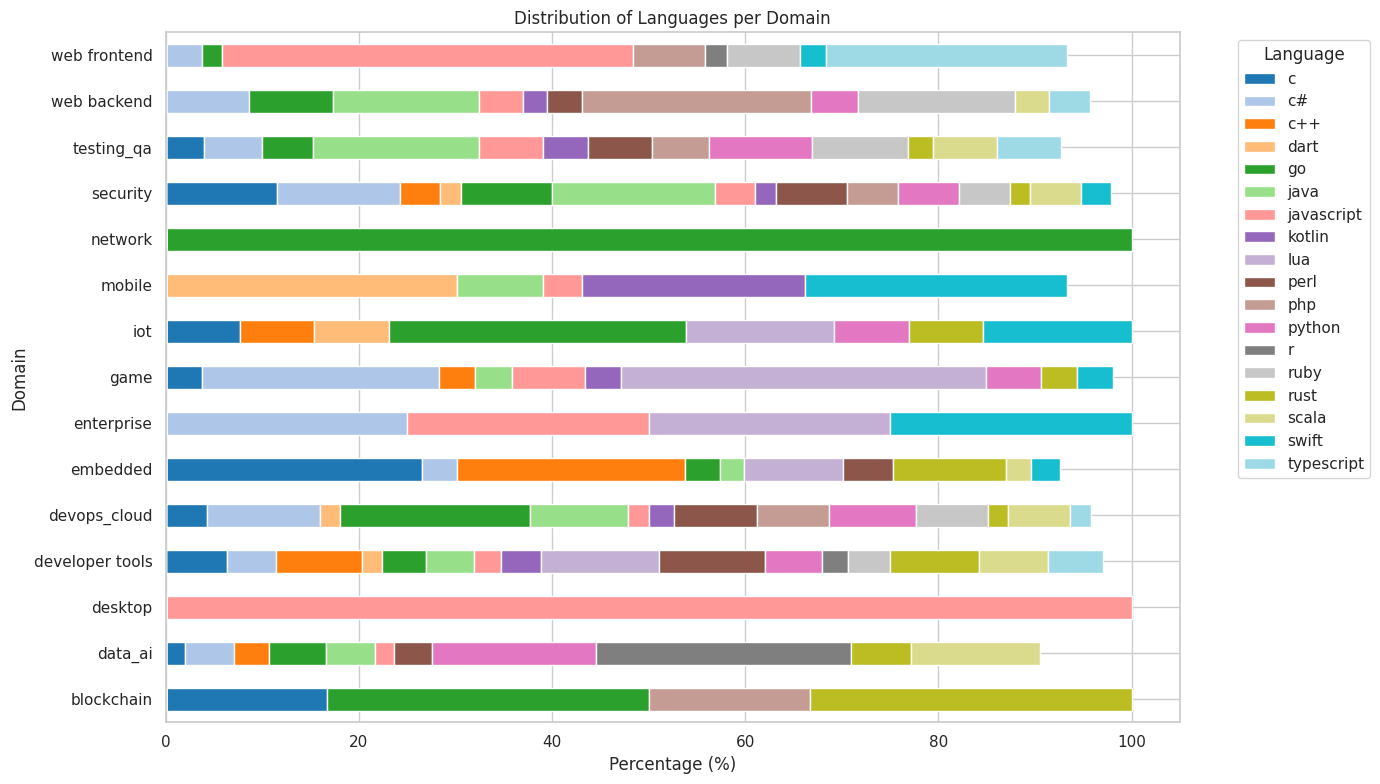

In [5]:
# Calculate percentages
domain_lang_counts = df_exploded.groupby(['label_gpt', 'language']).size().reset_index(name='count')
domain_total = df_exploded.groupby('label_gpt').size().reset_index(name='total')
domain_lang_pct = pd.merge(domain_lang_counts, domain_total, on='label_gpt')
domain_lang_pct['percentage'] = (domain_lang_pct['count'] / domain_lang_pct['total']) * 100

# Filter to show only significant languages (e.g., > 2% in that domain) to avoid clutter
domain_lang_pct = domain_lang_pct[domain_lang_pct['percentage'] > 2]

# Pivot for plotting
pivot_domain_lang = domain_lang_pct.pivot(index='label_gpt', columns='language', values='percentage').fillna(0)

# Plot Stacked Bar Chart
pivot_domain_lang.plot(kind='barh', stacked=True, colormap='tab20', figsize=(14, 8))
plt.title('Distribution of Languages per Domain')
plt.xlabel('Percentage (%)')
plt.ylabel('Domain')
plt.legend(title='Language', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 5. Trend Analysis

Visualize the trends of Domains over time.

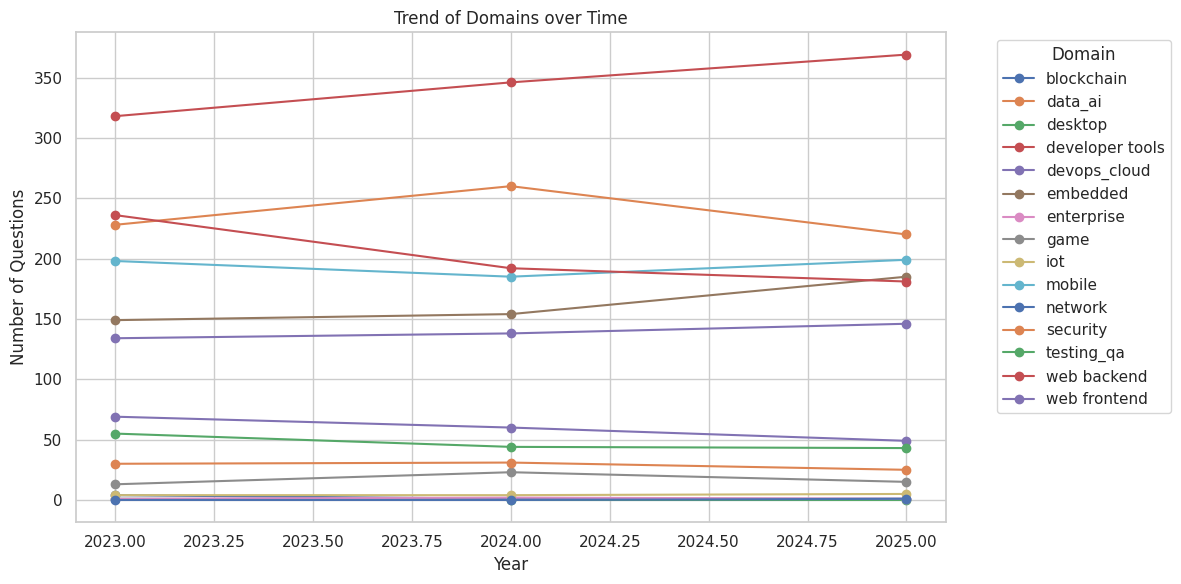

In [6]:
# Trend of Domains over Years
domain_trend = df.groupby(['event_date', 'label_gpt']).size().unstack().fillna(0)

# Plot
domain_trend.plot(kind='line', marker='o', figsize=(12, 6))
plt.title('Trend of Domains over Time')
plt.xlabel('Year')
plt.ylabel('Number of Questions')
plt.legend(title='Domain', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

### Trend of Top Languages over Time

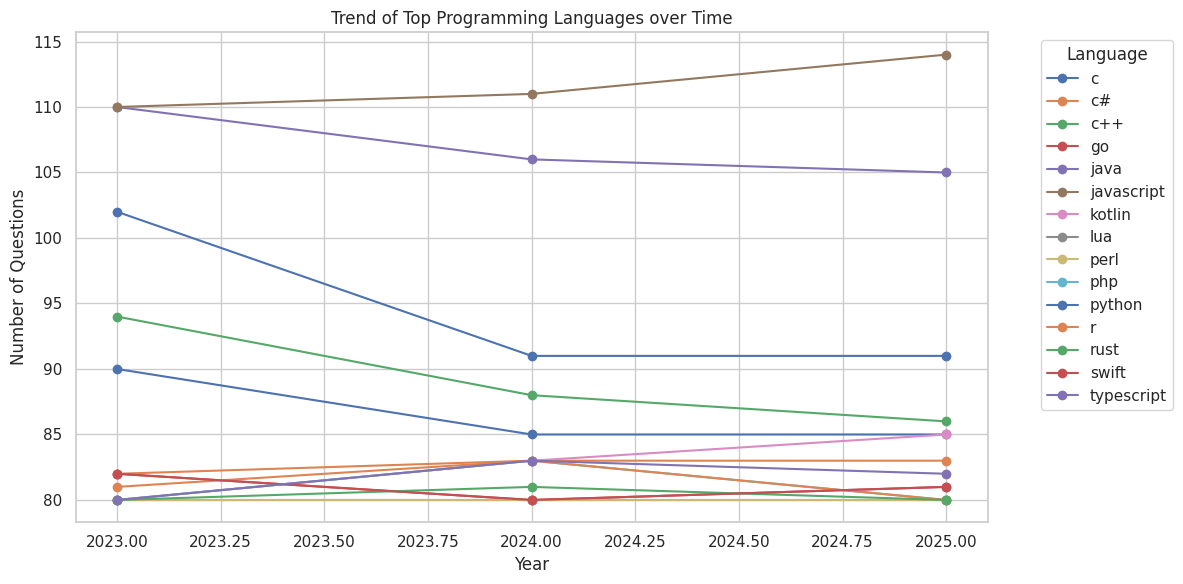

In [7]:
# Trend of Top Languages over Years
lang_trend = df_exploded[df_exploded['language'].isin(top_languages)].groupby(['event_date', 'language']).size().unstack().fillna(0)

# Plot
lang_trend.plot(kind='line', marker='o', figsize=(12, 6))
plt.title('Trend of Top Programming Languages over Time')
plt.xlabel('Year')
plt.ylabel('Number of Questions')
plt.legend(title='Language', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()